In [1]:
from torch import nn
import torch.nn.functional as F
import torch
from dreamer import DreamerMLP, unimix, probs_to_logits, Categorical, Normal, WeightedAverageOverBins, TargetNetwork, to_numpy
from rltesting.torch_rl.ppo.ppo import Rollout
import gymnasium as gym
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import SubprocVecEnv
from utils import compute_lambda_returns, compute_lambda_values
from matplotlib import pyplot as plt
import numpy as np

class Actor(nn.Module):
    def __init__(self):
        super().__init__()
        self.mlp = DreamerMLP(8, 4, 256, 2)
    
    def policy_dist(self, x):
        logits = self.mlp(x)
        probs = F.softmax(logits, -1)
        unimixed_probs = unimix(probs, 3)
        action_dist = Categorical(probs=unimixed_probs)
        return action_dist
    
    def sample_action(self, dist):
        if self.action_type == "discrete":
            action = dist.sample()
        else:
            action = dist.rsample()
        return action
    
    def policy_fn(self, x, det=False):
        # actually choosing the action, returns the actual action as well as the log prob of the action and entropy
        action_dist = self.policy_dist(x)
        if not det:
            action = self.sample_action(action_dist)
        else:
            return action_dist.mode
        return action.detach()
        
class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.mlp = DreamerMLP(8, 1, 256, 2)
    
    def forward(self, x):
        return self.mlp(x)

def make_env():
    def thunk():
        env = gym.make(f"LunarLander-v3", render_mode="rgb_array")
        env = gym.wrappers.RecordEpisodeStatistics(env)
        return env
    return thunk

In [7]:
range_ema = None

def train_actor(returns, values, action_log_probs, entropy, entropy_coef=3e-4):
    global range_ema
    range_ = torch.quantile(returns, 1 - 0.05) - torch.quantile(returns, 0.05)
    if range_ema is not None:
        range_ema = range_ * 0.02 + range_ema * (1 - 0.02)
    else:
        range_ema = range_
    actor_loss = -torch.mean(((returns - values) / torch.clip(range_ema, min=1)).detach() * action_log_probs + entropy * entropy_coef)
    return actor_loss, entropy.mean()

def train_critic(critic, critic_target, states, last_state, rewards, dones, gamma=0.99, lambda_=0.95):
    states = torch.cat([states, last_state.unsqueeze(0)], 0)
    critic_target.update()
    values = critic(states)
    value_target = critic_target(states)
    continues = (1 - dones)
    # returns = compute_advantage(values, rewards, dones) 
    # loss = F.mse_loss(values[:-1], returns.detach())
    # loss += F.mse_loss(values[:-1], value_target[:-1])    
    # return loss, returns.detach(), values.detach()[:-1]
    returns = compute_lambda_returns(values, rewards, continues, gamma, lambda_)
    loss = F.mse_loss(values[:-1], returns.detach())
    loss += F.mse_loss(values[:-1], value_target[:-1])
    return loss, returns.detach(), values.detach()[:-1]
    # loss = F.mse_loss(values[:-1], returns.detach()[:-1])
    # loss += F.mse_loss(values, value_target)
    # return loss, returns.detach(), values.detach()

def compute_advantage(values, rewards, done):
    q_target = rewards + 0.99 * values[1:] * (1 - done)
    return q_target - values[:-1]



In [8]:
env = make_vec_env(make_env(), 16, vec_env_cls=SubprocVecEnv, vec_env_kwargs=dict(start_method='spawn'))
device = 'cuda' if torch.cuda.is_available() else 'cpu'
actor = Actor().to(device)
critic = Critic().to(device)
actor_opt = torch.optim.Adam(actor.parameters(), 3e-4)
critic_opt = torch.optim.Adam(critic.parameters(), 3e-4)
critic_target = TargetNetwork(critic, 0.01)
rollout_length = 16
rollout = Rollout(rollout_length, 16, env.observation_space, env.action_space)
rewards = []
steps = []

/home/antony/anaconda3/envs/rltesting/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
/home/antony/anaconda3/envs/rltesting/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
/home/antony/anaconda3/envs/rltesting/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resour

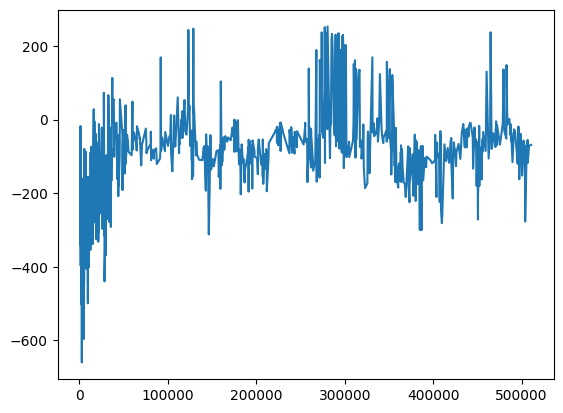

In [9]:
obs = env.reset()
for r in range(2000):
    log_probs = []
    entropies = []
    for i in range(rollout_length):
        action_dist = actor.policy_dist(torch.tensor(obs, device=device))
        action = action_dist.sample()
        log_prob = action_dist.log_prob(action)
        action = to_numpy(action.unsqueeze(1))
        log_probs.append(log_prob)
        entropies.append(action_dist.entropy())
        log_prob = to_numpy(log_prob)
        next_obs, reward, done, infos = env.step(action[:, 0])
        rollout.add(obs, action, reward, done, log_prob)
        obs = next_obs
        total_reward = 0
        num_completed = 0
        for info in infos:
            if 'episode' in info.keys():
                total_reward += info['episode']['r']
                num_completed += 1
        if num_completed > 0:
            rewards.append(total_reward / num_completed)
            steps.append((r * 16 + i) * 16)
    rollout.last_obs = obs
    obs, action, reward, done, log_prob, last_obs = rollout.unpack()
    # obs = np.concatenate([obs, rollout.last_obs[np.newaxis, :, :]])
    obs = torch.tensor(obs, device=device)
    action = torch.tensor(action, device=device)
    reward = torch.tensor(reward, device=device).unsqueeze(-1)
    done = torch.tensor(done, device=device).unsqueeze(-1)
    log_prob = torch.stack(log_probs).unsqueeze(-1)
    entropy = torch.stack(entropies).unsqueeze(-1)
    critic_loss, returns, values = train_critic(critic, critic_target, obs, torch.tensor(rollout.last_obs).to(device), reward, done)
    critic_loss.backward()
    critic_opt.step()
    critic_opt.zero_grad()
    actor_loss, entropy = train_actor(returns, values, log_prob, entropy)
    actor_loss.backward()
    actor_opt.step()
    actor_opt.zero_grad()
    obs = rollout.last_obs
    rollout.reset()
plt.plot(steps, rewards)

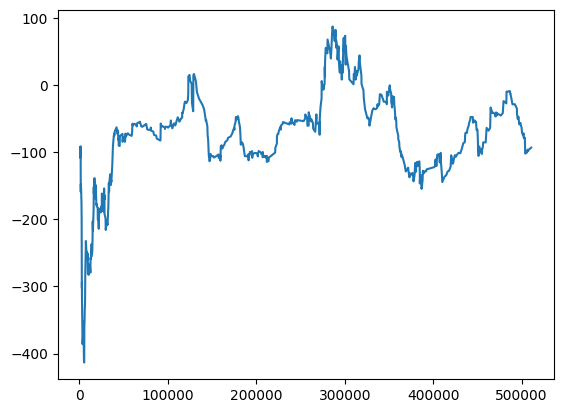

In [10]:
smoothed_rew = None
smoothed_rews = []
for reward in rewards:
    if smoothed_rew is None:
        smoothed_rew = reward
    else:
        smoothed_rew = smoothed_rew * 0.9 + 0.1 * reward
    smoothed_rews.append(smoothed_rew)
plt.plot(steps, smoothed_rews)